In [1]:
!pip install -U transformers>=4.46.0 accelerate>=1.2.0


In [2]:
# ── Verificar GPU ────────────────────────────────────────────────
import torch

if not torch.cuda.is_available():
    raise RuntimeError("⚠️ No hay GPU. Ve a: Entorno de ejecución → Cambiar tipo → GPU")

gpu_name = torch.cuda.get_device_name(0)
vram = torch.cuda.get_device_properties(0).total_memory / 1e9   # ← corregido
print(f"✅ GPU: {gpu_name}")
print(f"   VRAM: {vram:.1f} GB")
print(f"   PyTorch: {torch.__version__}")

# ── Montar Google Drive ──────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# Carpeta del proyecto en Drive (se crea si no existe)
import os
PROJECT = "/content/drive/MyDrive/Diplomado_FM/Modulo3"
os.makedirs(f"{PROJECT}/models/phi4mini_full_ft", exist_ok=True)
os.makedirs(f"{PROJECT}/reports", exist_ok=True)
os.makedirs(f"{PROJECT}/data", exist_ok=True)
print(f"\n📁 Proyecto en: {PROJECT}")



✅ GPU: NVIDIA A100-SXM4-40GB
   VRAM: 42.4 GB
   PyTorch: 2.11.0+cu128
Mounted at /content/drive

📁 Proyecto en: /content/drive/MyDrive/Diplomado_FM/Modulo3


In [3]:
# Opción A: Subir archivos directamente desde tu Mac
from google.colab import files
import shutil

DATA_DIR = f"{PROJECT}/data"

print("📤 Sube train.jsonl y val.jsonl desde tu Mac")
print("   (están en: sec_data/instructions/)\n")

uploaded = files.upload()  # Se abre el selector de archivos

for filename in uploaded:
    dest = os.path.join(DATA_DIR, filename)
    shutil.move(filename, dest)
    print(f"   ✅ {filename} → {dest}")

# Verificar
for f in ["train.jsonl", "val.jsonl"]:
    path = os.path.join(DATA_DIR, f)
    if os.path.exists(path):
        lines = sum(1 for _ in open(path))
        print(f"   {f}: {lines:,} ejemplos")
    else:
        print(f"   ⚠️ {f} no encontrado")


📤 Sube train.jsonl y val.jsonl desde tu Mac
   (están en: sec_data/instructions/)



Saving train.jsonl to train.jsonl
Saving val.jsonl to val.jsonl
   ✅ train.jsonl → /content/drive/MyDrive/Diplomado_FM/Modulo3/data/train.jsonl
   ✅ val.jsonl → /content/drive/MyDrive/Diplomado_FM/Modulo3/data/val.jsonl
   train.jsonl: 10,147 ejemplos
   val.jsonl: 1,791 ejemplos


In [4]:
import json
from datasets import load_dataset, DatasetDict

dataset = DatasetDict({
    "train": load_dataset("json", data_files=f"{DATA_DIR}/train.jsonl", split="train"),
    "validation": load_dataset("json", data_files=f"{DATA_DIR}/val.jsonl", split="train"),
})

print(f"Train:      {len(dataset['train']):,} ejemplos")
print(f"Validation: {len(dataset['validation']):,} ejemplos")
print(f"\nColumnas: {dataset['train'].column_names}")
print(f"\nEjemplo:\n{json.dumps(dataset['train'][0], indent=2, ensure_ascii=False)[:500]}")


Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Train:      10,147 ejemplos
Validation: 1,791 ejemplos

Columnas: ['instruction', 'input', 'output']

Ejemplo:
{
  "instruction": "Summarize the revenue performance described in the following SEC filing excerpt.",
  "input": "s moving beyond 2D screens toward immersive experiences like augmented and virtual reality to help build the metaverse, which we believe is the next evolution in social technology.\nWe report financial results for two segments: Family of Apps (FoA) and Reality Labs (RL). For FoA, we generate substantially all of our revenue from selling advertising placements to marketers. Ads on ou


In [5]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_ID = "microsoft/Phi-4-mini-instruct"

# ── Tokenizer ─────────────────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# ── Modelo ────────────────────────────────────────────────────────
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)
model.config.use_cache = False
model.gradient_checkpointing_enable()

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Modelo cargado: {total/1e9:.1f}B params — {trainable/total*100:.1f}% entrenables")






config.json:   0%|          | 0.00/2.50k [00:00<?, ?B/s]

[transformers] This model config has set a `rope_parameters['original_max_position_embeddings']` field, to be used together with `max_position_embeddings` to determine a scaling factor. Please set the `factor` field of `rope_parameters`with this ratio instead -- we recommend the use of this field over `original_max_position_embeddings`, as it is compatible with most model architectures.


tokenizer_config.json:   0%|          | 0.00/2.93k [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 15.5MB            

tokenizer.json: downloading bytes:           |  0.00B            

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/194 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

✅ Modelo cargado: 3.8B params — 100.0% entrenables


In [6]:
MAX_SEQ_LEN = 1024   # T4=1024, A100=2048

SYSTEM_PROMPT = (
    "You are a financial analyst assistant specialized in SEC filings. "
    "Answer accurately based on the provided context from 10-Q reports."
)

def format_chat(example):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": f"{example['instruction']}\n\nContext:\n{example['input']}"},
    ]
    if "output" in example and example["output"]:
        messages.append({"role": "assistant", "content": example["output"]})

    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=False
    )
    return {"text": text}

dataset = dataset.map(format_chat, remove_columns=dataset["train"].column_names)
print(f"Ejemplo formateado:\n{dataset['train'][0]['text'][:500]}")


Map:   0%|          | 0/10147 [00:00<?, ? examples/s]

Map:   0%|          | 0/1791 [00:00<?, ? examples/s]

Ejemplo formateado:
<|system|>You are a financial analyst assistant specialized in SEC filings. Answer accurately based on the provided context from 10-Q reports.<|end|><|user|>Summarize the revenue performance described in the following SEC filing excerpt.

Context:
s moving beyond 2D screens toward immersive experiences like augmented and virtual reality to help build the metaverse, which we believe is the next evolution in social technology.
We report financial results for two segments: Family of Apps (FoA) and 


In [7]:
def tokenize(example):
    out = tokenizer(
        example["text"],
        truncation=True,
        max_length=MAX_SEQ_LEN,
        padding=False,
    )
    out["labels"] = out["input_ids"].copy()
    return out

tokenized = dataset.map(tokenize, remove_columns=["text"], batched=False)
print(f"Tokens ejemplo 0: {len(tokenized['train'][0]['input_ids'])}")
print(f"Columnas: {tokenized['train'].column_names}")


Map:   0%|          | 0/10147 [00:00<?, ? examples/s]

Map:   0%|          | 0/1791 [00:00<?, ? examples/s]

Tokens ejemplo 0: 741
Columnas: ['input_ids', 'attention_mask', 'labels']


In [8]:
from transformers import TrainingArguments, Trainer, DataCollatorForLanguageModeling, EarlyStoppingCallback
import math

# ── Rutas ─────────────────────────────────────────────────────────
PROJECT      = "/content/drive/MyDrive/phi4mini_full_ft"
OUTPUT_MODEL = f"{PROJECT}/model"
REPORT_DIR   = f"{PROJECT}/reports"

# ── Calcular warmup_steps (equivalente a warmup_ratio=0.05) ──────
EPOCHS     = 3
BATCH_SIZE = 1
GRAD_ACCUM = 16
total_steps = math.ceil(len(tokenized["train"]) / (BATCH_SIZE * GRAD_ACCUM)) * EPOCHS
warmup = int(total_steps * 0.05)
print(f"📊 Steps totales estimados: {total_steps} | Warmup steps: {warmup}")

# ── TrainingArguments (solo parámetros válidos v5.15) ─────────────
training_args = TrainingArguments(
    output_dir=OUTPUT_MODEL,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=2e-5,
    warmup_steps=warmup,
    weight_decay=0.01,
    bf16=True,
    gradient_checkpointing=True,
    eval_strategy="steps",
    eval_steps=50,
    save_only_model=True,    # ← AGREGAR: evita guardar el optimizador (~15 GB)
    save_strategy="steps",
    save_steps=200,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    logging_steps=10,
    report_to="tensorboard",
    dataloader_num_workers=2,
    run_name="phi4mini_full_ft",
)

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

print("🚀 Iniciando entrenamiento...")
result = trainer.train()
print(f"✅ Entrenamiento completado — Loss final: {result.training_loss:.4f}")



📊 Steps totales estimados: 1905 | Warmup steps: 95
🚀 Iniciando entrenamiento...


Step,Training Loss,Validation Loss
50,1.567274,1.651114
100,1.468633,1.517196
150,1.366992,1.423171
200,1.312727,1.355906
250,1.283256,1.293979
300,1.180700,1.243313
350,1.155686,1.197202
400,1.170138,1.152865
450,1.068355,1.115221
500,1.027869,1.086465


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


✅ Entrenamiento completado — Loss final: 0.9569


In [9]:
# Guardar SOLO el modelo final y tokenizer en Drive (una vez, ~7.6 GB)
DRIVE_DIR = "/content/drive/MyDrive/diplomado/models/phi4mini_full_ft"
os.makedirs(DRIVE_DIR, exist_ok=True)

print("💾 Guardando modelo final en Drive...")
trainer.save_model(DRIVE_DIR)
tokenizer.save_pretrained(DRIVE_DIR)

# Guardar métricas (archivo pequeño)
import json
metrics = {
    "train_loss": result.training_loss,
    "train_steps": result.global_step,
    "eval_results": trainer.evaluate(),
}
with open(f"{DRIVE_DIR}/phi4mini_full_ft_summary.json", "w") as f:
    json.dump(metrics, f, indent=2)

print(f"✅ Modelo guardado en: {DRIVE_DIR}")


💾 Guardando modelo final en Drive...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Step
0.740470,0.843278,1905


✅ Modelo guardado en: /content/drive/MyDrive/diplomado/models/phi4mini_full_ft


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/phi4mini_full_ft/reports/phi4mini_full_ft_loss.png'

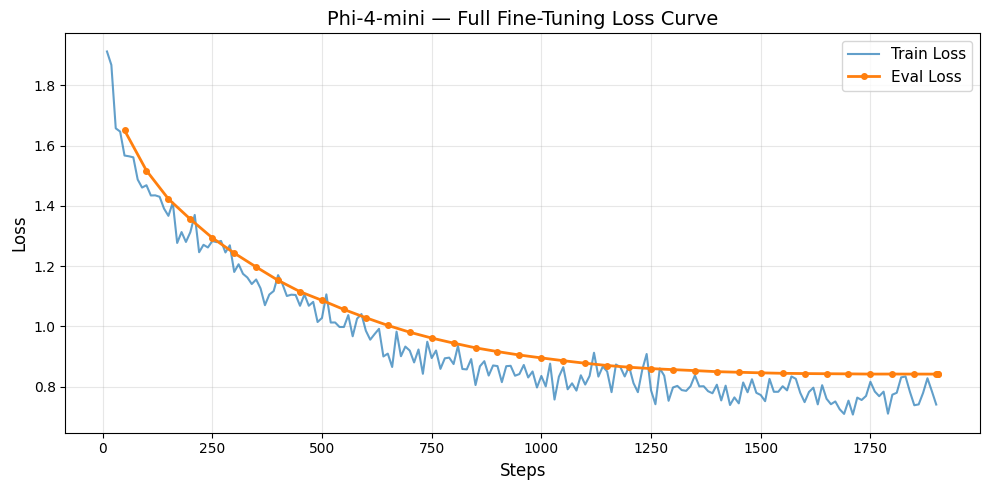

In [10]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_steps = [x["step"] for x in log_history if "loss" in x]
train_loss  = [x["loss"] for x in log_history if "loss" in x]
eval_steps  = [x["step"] for x in log_history if "eval_loss" in x]
eval_loss   = [x["eval_loss"] for x in log_history if "eval_loss" in x]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_steps, train_loss, label="Train Loss", alpha=0.7, linewidth=1.5)
ax.plot(eval_steps, eval_loss, label="Eval Loss", marker="o", markersize=4, linewidth=2)
ax.set_xlabel("Steps", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.set_title("Phi-4-mini — Full Fine-Tuning Loss Curve", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()

plot_path = f"{PROJECT}/reports/phi4mini_full_ft_loss.png"
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"📈 Gráfica guardada: {plot_path}")


In [12]:
# ── Celda: Prueba de Inferencia ──────────────────────────────────────────

from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

# ── 1. Ruta del modelo entrenado ──
MODEL_PATH = "/content/drive/MyDrive/diplomado/models/phi4mini_full_ft"

# ── 2. Cargar modelo y tokenizer ──
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)
model.eval()
print(f"✅ Modelo cargado desde: {MODEL_PATH}")
print(f"   Device: {model.device}")

# ── 3. Función de inferencia ──
def ask(question, max_new_tokens=512, temperature=0.7):
    messages = [
        {"role": "system", "content": "You are a financial analyst assistant specialized in SEC filings analysis."},
        {"role": "user", "content": question}
    ]

    prompt = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            top_p=0.9,
            do_sample=True,
            pad_token_id=tokenizer.pad_token_id
        )

    # Decodificar solo los tokens generados (sin el prompt)
    response = tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    )
    return response

# ── 4. Preguntas de prueba ──
test_questions = [
    "What are the main risk factors disclosed in a typical 10-K filing?",
    "Summarize the key components of an SEC annual report.",
    "What is the difference between a 10-K and a 10-Q filing?",
]

for i, q in enumerate(test_questions, 1):
    print(f"\n{'='*70}")
    print(f"📌 Pregunta {i}: {q}")
    print(f"{'='*70}")
    answer = ask(q)
    print(f"\n🤖 Respuesta:\n{answer}")


Loading weights:   0%|          | 0/194 [00:00<?, ?it/s]

✅ Modelo cargado desde: /content/drive/MyDrive/diplomado/models/phi4mini_full_ft
   Device: cuda:0

📌 Pregunta 1: What are the main risk factors disclosed in a typical 10-K filing?

🤖 Respuesta:
In a typical 10-K filing, the main risk factors disclosed are found in the sections titled "Risk Factors" and "Management's Discussion and Analysis of Financial Condition and Results of Operations." Under "Risk Factors," the company outlines various risks that could harm the business, including financial risks, market risks, legal and regulatory risks, operational risks, and industry-specific risks. These risks are presented in the order in which they appear in the Form 10-K.

📌 Pregunta 2: Summarize the key components of an SEC annual report.

🤖 Respuesta:
An SEC annual report, specifically the Form 10-K, contains several key components that provide a comprehensive overview of a company's financial performance and strategic direction. These components include:


1. **Business Overview and Corp